In [17]:
import nltk
import pandas as pd
import re
import string 
import numpy as np 

nltk.download("all")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import emoji
import contractions
from bs4 import BeautifulSoup
from textblob import TextBlob

import matplotlib.pyplot as plt

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

In [18]:
splits = {"train": "data/train-00000-of-00001.parquet", "test": "data/test-00000-of-00001.parquet"}
df_train = pd.read_parquet("hf://datasets/wangrongsheng/ag_news/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/wangrongsheng/ag_news/" + splits["test"])

In [19]:
df_train.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


Text(0.5, 1.0, 'Train Label Distribution')

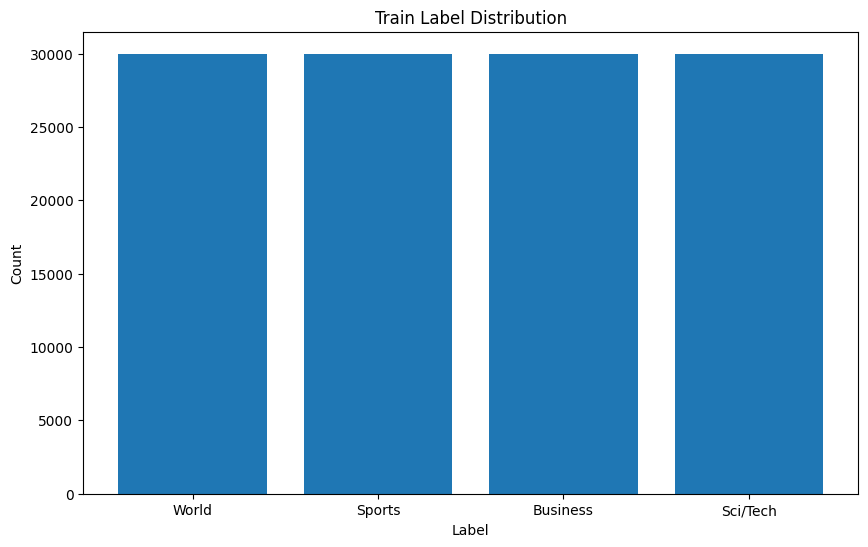

In [20]:
plt.figure(figsize=(10,6))
plt.bar(
    ["World", "Sports", "Business", "Sci/Tech"],
    df_train['label'].value_counts().values)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title("Train Label Distribution")

In [21]:
def clean_text(text):
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = contractions.fix(text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"\d+", "", text)
    text = " ".join(text.split())

    stopword = set(stopwords.words("english"))
    text = ' '.join([word for word in text.split() if word not in stopword])
    text = emoji.demojize(text)
    return text

In [22]:
sample = """
Check out this AMAZING article!!! https://example.com 😊 I'm 100% sure you'll love it, or you can visit ://test.com. <p>It is <b>very</b> informative!</p>
"""
print(clean_text(sample))

check amazing article :smiling_face_with_smiling_eyes: sure love visit testcom pit bveryb informativep


In [23]:
df_train["clean_text"] = df_train["text"].apply(clean_text)
df_test["clean_text"] = df_test["text"].apply(clean_text)

In [24]:
df_train.head()

,text,label,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,wall st bears claw back black reuters reuters ...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,oil economy cloud stocks outlook reuters reute...
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,iraq halts oil exports main southern pipeline ...
4,"Oil prices soar to all-time record, posing new...",2,oil prices soar alltime record posing new mena...


## Classification

In [25]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [26]:
X_train, y_train = df_train["clean_text"], df_train["label"]
X_test, y_test = df_test["clean_text"], df_test["label"]

In [34]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

param_grid = [
    {
        "vectorizer": [TfidfVectorizer()],
        "classifier": [RandomForestClassifier()],
        "vectorizer__ngram_range": [(1, 1)],
        "classifier__n_estimators": [100],
        "classifier__max_depth": [None, 10]
    },
    #{
    #    "vectorizer": [TfidfVectorizer()],
    #    "classifier": [SVC()],
    #    "vectorizer__ngram_range": [(1, 2)],
    #    "classifier__C": [1, 10],
    #    "classifier__kernel": ["linear", "rbf"]
    #}
]

In [35]:
param_grid

[{'vectorizer': [TfidfVectorizer()],
  'classifier': [RandomForestClassifier()],
  'vectorizer__ngram_range': [(1, 1)],
  'classifier__n_estimators': [100],
  'classifier__max_depth': [None, 10]}]

In [ ]:
grid = GridSearchCV(
    pipeline,
    param_grid, 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


In [ ]:
y_pred = grid.predict(X_test)
print("Best Parameters:", grid.best_params_)
print("Best Model Score:", grid.best_score_)
print("Best Model:", grid.best_estimator_)

cm = classification_report(y_test, y_pred,
                           target_names=['World', 'Sports', 'Business', 'Sci/Tech'])

print("Classification Report:\n", cm)


In [ ]:
plt.Figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=['World', 'Sports', 'Business', 'Sci/Tech'], yticklabels=['World', 'Sports', 'Business', 'Sci/Tech'])
plt.legend(title="Confusion Matrix")
plt.title("Confusion Matrix")
plt.show()